In [118]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc, accuracy_score
from scipy.special import softmax

NUM_CLASSES = 1000
path = "/Users/dkrivogub/Documents/vm_data/target_dir"

In [119]:
def f(file_path):
    data = np.load(file_path)
    logits = data["logits"].astype(np.float32)
    labels = data["labels"].astype(np.int64)

    probs = softmax(logits, axis=1)

    pred_labels = np.argmax(probs, axis=1)
    acc = accuracy_score(labels, pred_labels)

    # правильность предсказания
    correctness_labels = (pred_labels == labels).astype(int)

    # вероятность истинного класса
    p_true = probs[np.arange(len(labels)), labels]

    # если угадали -> p_true
    # если не угадали -> 1 - p_true
    scores = np.where(correctness_labels == 1, p_true, 1 - p_true)

    # alternative approach
    # scores = p_true

    fpr, tpr, _ = roc_curve(correctness_labels, scores)
    roc_auc = auc(fpr, tpr)

    return fpr, tpr, roc_auc, acc


def get_lr_str(learning_rate):
    return f"{learning_rate:.10f}".rstrip("0").rstrip(".").replace(".", "_")


def plot_val_correctness_roc_curves(
    start_epoch,
    end_epoch,
    learning_rate,
    fontsize,
    val_data_dir=path,
    location="lower right",
):
    val_data_dir = Path(val_data_dir)
    lr_str = get_lr_str(learning_rate)
    plt.figure(figsize=(10, 8))

    for epoch in range(start_epoch, end_epoch + 1):
        file_path = val_data_dir / f"val_data_lr_{lr_str}_epoch_{epoch}.npz"
        fpr, tpr, roc_auc, acc = f(file_path)
        plt.plot(fpr, tpr, linewidth=2, label=f"Epoch {epoch} | ROC-AUC = {roc_auc:.4f} | Accuracy = {acc:.4f}")
        print(f"Epoch {epoch} | ROC-AUC = {roc_auc:.4f} | Accuracy = {acc:.4f}")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title("ROC Curves for ViT-B/16 on ImageNet-1k\n" f"Learning Rate = {learning_rate}")
    plt.legend(loc=location, fontsize=fontsize)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"val_plot_lr_{lr_str}.png", dpi=300)
    plt.show()

In [120]:
def plot_test_rocs(
    lst,  # list of (lr, epoch_num, target_subdir)
    test_data_dir=path,
    location="lower right",
):
    test_data_dir = Path(test_data_dir)
    plt.figure(figsize=(10, 8))

    for learning_rate, epoch, target_subdir in lst:
        lr_str = get_lr_str(learning_rate)
        file_path = test_data_dir / target_subdir / f"test_data_lr_{lr_str}_epoch_{epoch}.npz"
        fpr, tpr, roc_auc, acc = f(file_path)
        plt.plot(fpr, tpr, linewidth=2, label=f"LR = {learning_rate:.3f} | ROC-AUC = {roc_auc:.4f} | Acc = {acc:.4f}")
        print(f"LR = {learning_rate:.3f} | ROC-AUC = {roc_auc:.4f} | Acc = {acc:.4f}")

    plt.title("ROC Curves for Best ViT-B/16 Checkpoints Across Learning Rates\n" f"LRs = {[lr for lr, _, _ in lst]}")
    plt.legend(loc=location, fontsize=18)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"test_plot.png", dpi=300)
    plt.show()

In [121]:
def plot_test_accuracy_vs_angle(target_dir=Path(path) / "lr_0001"):
    plt.figure(figsize=(10, 8))

    learning_rate = 0.001
    epoch = 9
    lr_str = get_lr_str(learning_rate)

    angles = list(range(0, 81, 10))  # 10,20,...,80
    accuracies = []

    for angle in angles:
        file_path = target_dir / f"test_data_lr_{lr_str}_epoch_{epoch}_angle_{angle}.npz"
        _, _, _, acc = f(file_path)
        accuracies.append(acc)
        print(f"Angle = {angle}° | Accuracy = {acc:.4f}")

    plt.plot(
        angles,
        accuracies,
        marker="o",
        linewidth=2,
    )
    plt.xlabel("Rotation Angle (degrees)", fontsize=14)
    plt.ylabel("Accuracy", fontsize=14)
    plt.title(f"Accuracy vs Rotation Angle\nLR = {learning_rate:.3f}, Epoch = {epoch}")
    plt.xticks(angles)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("test_accuracy_vs_angle.png", dpi=300)
    plt.show()

In [122]:
def plot_test_accuracy_vs_angle_train(
    epoch_num: int,
    train_angle: int,
    location: str = "lower left",
    target_dir: Path = Path(path),
):
    plt.figure(figsize=(10, 8))

    lr_str = get_lr_str(0.001)
    target_subdir = f"angle_{train_angle}"

    accuracies = []
    testing_angles = [x for x in range(0, 81, 10)]

    for test_angle in testing_angles:
        file_path = target_dir / target_subdir / f"test_data_lr_{lr_str}_epoch_{epoch_num}_angle_{test_angle}.npz"

        _, _, _, acc = f(file_path)
        accuracies.append(acc)

        print(f"Train angle = {train_angle}° | " f"Test angle = {test_angle}° | " f"Accuracy = {acc:.4f}")

    plt.plot(
        testing_angles,
        accuracies,
        marker="o",
        linewidth=2,
        label=f"Train rotation range: [-{train_angle}°, {train_angle}°]",
    )

    plt.xlabel("Maximum Test Rotation Angle n (degrees)", fontsize=14)
    plt.ylabel("Accuracy", fontsize=14)

    plt.title(
        "Test Accuracy vs Max Test Rotation Range\n"
        f"Model trained with rotations in [-{train_angle}°, {train_angle}°]"
    )

    plt.xticks(testing_angles)
    plt.grid(True)
    plt.legend(loc=location, fontsize=12)
    plt.tight_layout()

    plt.savefig(f"test_accuracy_train_angle_{train_angle}.png", dpi=300)
    plt.show()

In [123]:
train_angle_and_best_epoch = [
    (0, 9),
    (10, 10),
    (20, 10),
    (30, 10),
    (40, 10),
    (50, 9),
    (60, 10),
    (70, 9),
    (80, 8),
]

# for max_rotation_degrees, epoch_num in train_angle_and_best_epoch:
#     plot_test_accuracy_vs_angle_train(epoch_num=epoch_num, train_angle=max_rotation_degrees)

In [124]:
def plot_all_train_angles_accuracy(
    train_angle_and_best_epoch: list[tuple[int, int]],
    filename: str,
    location: str = "lower left",
    target_dir: Path = Path(path),
    testing_angles: list = [x for x in range(0, 81, 10)],
):
    plt.figure(figsize=(12, 8))

    lr_str = get_lr_str(0.001)

    for train_angle, epoch_num in train_angle_and_best_epoch:
        target_subdir = f"angle_{train_angle}"
        accuracies = []

        for test_angle in testing_angles:
            file_path = target_dir / target_subdir / f"test_data_lr_{lr_str}_epoch_{epoch_num}_angle_{test_angle}.npz"

            _, _, _, acc = f(file_path)
            accuracies.append(acc)

            print(
                f"Train angle = {train_angle}° | "
                f"Epoch = {epoch_num} | "
                f"Test angle = {test_angle}° | "
                f"Accuracy = {acc:.4f}"
            )

        if train_angle == 0:
            label = "No rotation augmentation"
            linestyle = "--"
            linewidth = 3
        else:
            label = f"Train range: ±{train_angle}°"
            linestyle = "-"
            linewidth = 2

        plt.plot(
            testing_angles,
            accuracies,
            marker="o",
            linewidth=linewidth,
            linestyle=linestyle,
            label=label,
        )

    plt.xlabel("Maximum Test Rotation Angle n (degrees)", fontsize=14)
    plt.ylabel("Accuracy", fontsize=14)

    plt.title("Test Accuracy vs Max Test Rotation Range\n" "Models trained with different rotation augmentation ranges")

    plt.xticks(testing_angles)
    plt.grid(True)
    plt.legend(loc=location, fontsize=11)
    plt.tight_layout()

    plt.savefig(filename, dpi=300)
    plt.show()

In [125]:
# plot_all_train_angles_accuracy(train_angle_and_best_epoch, filename="test_accuracy_all_train_angles.png")

In [126]:
# plot_all_train_angles_accuracy(
#     train_angle_and_best_epoch, filename="0-40_test_angle.png", testing_angles=[x for x in range(0, 41, 10)]
# )

In [127]:
def plot_all_train_angles_roc_auc(
    train_angle_and_best_epoch: list[tuple[int, int]],
    filename: str,
    location: str = "lower left",
    target_dir: Path = Path(path),
    testing_angles: list = [x for x in range(0, 81, 10)],
):
    plt.figure(figsize=(12, 8))

    lr_str = get_lr_str(0.001)

    for train_angle, epoch_num in train_angle_and_best_epoch:
        target_subdir = f"angle_{train_angle}"
        roc_aucs = []

        for test_angle in testing_angles:
            file_path = target_dir / target_subdir / f"test_data_lr_{lr_str}_epoch_{epoch_num}_angle_{test_angle}.npz"

            _, _, roc_auc, _ = f(file_path)
            roc_aucs.append(roc_auc)

            print(
                f"Train angle = {train_angle}° | "
                f"Epoch = {epoch_num} | "
                f"Test angle = {test_angle}° | "
                f"ROC-AUC = {roc_auc:.4f}"
            )

        if train_angle == 0:
            label = "No rotation augmentation"
            linestyle = "--"
            linewidth = 3
        else:
            label = f"Train range: ±{train_angle}°"
            linestyle = "-"
            linewidth = 2

        plt.plot(
            testing_angles,
            roc_aucs,
            marker="o",
            linewidth=linewidth,
            linestyle=linestyle,
            label=label,
        )

    plt.xlabel("Maximum Test Rotation Angle n (degrees)", fontsize=14)
    plt.ylabel("ROC-AUC", fontsize=14)

    plt.title("Test ROC-AUC vs Max Test Rotation Range\n" "Models trained with different rotation augmentation ranges")

    plt.xticks(testing_angles)
    plt.grid(True)
    plt.legend(loc=location, fontsize=11)
    plt.tight_layout()

    plt.savefig(filename, dpi=300)
    plt.show()

Train angle = 0° | Epoch = 9 | Test angle = 0° | ROC-AUC = 0.5815
Train angle = 0° | Epoch = 9 | Test angle = 10° | ROC-AUC = 0.5841
Train angle = 0° | Epoch = 9 | Test angle = 20° | ROC-AUC = 0.5737
Train angle = 0° | Epoch = 9 | Test angle = 30° | ROC-AUC = 0.5700
Train angle = 0° | Epoch = 9 | Test angle = 40° | ROC-AUC = 0.5546
Train angle = 0° | Epoch = 9 | Test angle = 50° | ROC-AUC = 0.5384
Train angle = 0° | Epoch = 9 | Test angle = 60° | ROC-AUC = 0.5192
Train angle = 0° | Epoch = 9 | Test angle = 70° | ROC-AUC = 0.4989
Train angle = 0° | Epoch = 9 | Test angle = 80° | ROC-AUC = 0.4663
Train angle = 10° | Epoch = 10 | Test angle = 0° | ROC-AUC = 0.6164
Train angle = 10° | Epoch = 10 | Test angle = 10° | ROC-AUC = 0.6236
Train angle = 10° | Epoch = 10 | Test angle = 20° | ROC-AUC = 0.6171
Train angle = 10° | Epoch = 10 | Test angle = 30° | ROC-AUC = 0.6075
Train angle = 10° | Epoch = 10 | Test angle = 40° | ROC-AUC = 0.5886
Train angle = 10° | Epoch = 10 | Test angle = 50° | RO

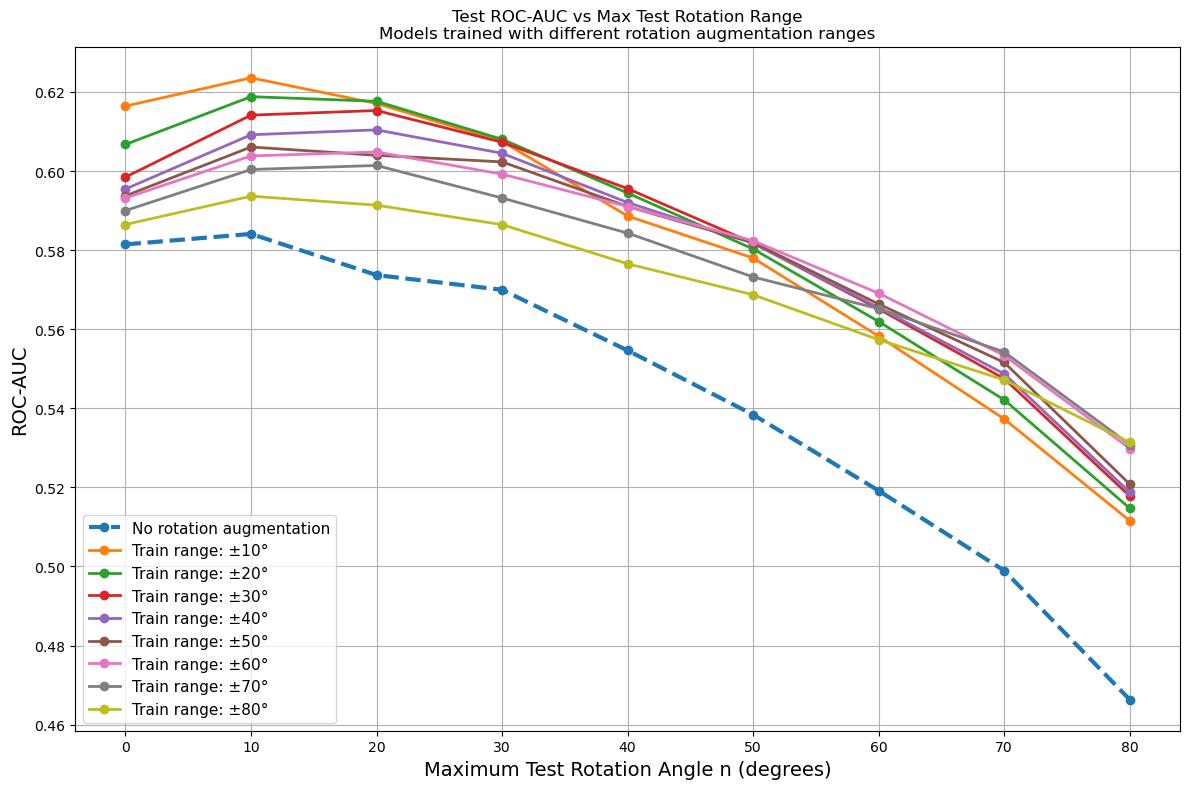

In [128]:
plot_all_train_angles_roc_auc(train_angle_and_best_epoch, filename="test_roc_auc_all_train_angles.png")

In [129]:
def collect_all_train_angles_roc_auc(
    train_angle_and_best_epoch: list[tuple[int, int]],
    target_dir: Path = Path(path),
    testing_angles: list = [x for x in range(0, 81, 10)],
):
    lr_str = get_lr_str(0.001)

    rows = []

    for train_angle, epoch_num in train_angle_and_best_epoch:
        target_subdir = f"angle_{train_angle}"

        for test_angle in testing_angles:
            file_path = target_dir / target_subdir / f"test_data_lr_{lr_str}_epoch_{epoch_num}_angle_{test_angle}.npz"

            _, _, roc_auc, _ = f(file_path)

            rows.append(
                {
                    "Train angle": train_angle,
                    "Epoch": epoch_num,
                    "Test angle": test_angle,
                    "ROC-AUC": roc_auc,
                }
            )

    return pd.DataFrame(rows)

In [130]:
df = collect_all_train_angles_roc_auc(train_angle_and_best_epoch)

table = df.pivot(
    index="Train angle",
    columns="Test angle",
    values="ROC-AUC",
)

In [ ]:
styled_table = (
    table.style.format("{:.4f}")
    .background_gradient(axis=None)
    .set_caption("ROC-AUC for models trained with different rotation ranges")
)

styled_table

Test angle,0,10,20,30,40,50,60,70,80
Train angle,,,,,,,,,
0,0.5815,0.5841,0.5737,0.5700,0.5546,0.5384,0.5192,0.4989,0.4663
10,0.6164,0.6236,0.6171,0.6075,0.5886,0.5780,0.5582,0.5373,0.5115
20,0.6067,0.6188,0.6176,0.6080,0.5944,0.5803,0.5619,0.5421,0.5147
30,0.5985,0.6141,0.6153,0.6073,0.5956,0.5818,0.5651,0.5475,0.5178
40,0.5955,0.6092,0.6104,0.6045,0.5920,0.5818,0.5654,0.5487,0.5188
50,0.5937,0.6061,0.6040,0.6023,0.5910,0.5819,0.5664,0.5516,0.5208
60,0.5932,0.6038,0.6048,0.5992,0.5910,0.5824,0.5691,0.5533,0.5298
70,0.5900,0.6004,0.6014,0.5932,0.5843,0.5732,0.5652,0.5542,0.5308
80,0.5865,0.5936,0.5914,0.5864,0.5765,0.5687,0.5573,0.5472,0.5314


In [ ]:
import dataframe_image as dfi

styled_table = (
    table.style.format("{:.4f}")
    .background_gradient(axis=None)
    .set_caption("ROC-AUC for models trained with different rotation ranges")
)

dfi.export(
    styled_table,
    "styled_table.png",
    table_conversion="matplotlib",
    dpi=300,
)